In [53]:

# NOTEBOOK 02: FEATURE ENGINEERING & TARGET CREATION
# KDHS ECD Delay Prediction Project

"""
Study Scope: Children aged 36-59 months only
Methodology: UNICEF ECDI2030 (SDG Indicator 4.2.1 Compliant)

This notebook:
1. Loads cleaned data from Notebook 01
2. Creates UNICEF-aligned target variables (composite + 4 domains)
3. Engineers final features for modeling
4. Handles missing data with appropriate imputation
5. Encodes categorical variables
6. Creates stratified train/test splits
7. Saves final modeling datasets for Notebook 03
"""

# Imports & Setup
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent))

from src.data import (
    get_data_paths, DOMAIN_ITEMS, ECD_COLS, recode_ecd_items
)
from src.targets import (
    create_all_targets, 
    make_unicef_composite_target,
    make_domain_scores,
    make_domain_targets,
    print_target_summary_36_59,
    UNICEF_THRESHOLDS_36_59
)

plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

print("Imports successful")
print(f"Python version: {sys.version.split()[0]}")
print(f"Pandas version: {pd.__version__}")

paths = get_data_paths()
print(f"\nProject Root: {paths['root']}")
print(f"Processed Data: {paths['processed']}")
print(f"Models: {paths['models']}")
print(f"Tables: {paths['tables']}")

Imports successful
Python version: 3.10.14
Pandas version: 2.0.3

Project Root: /Users/collinsbiwott/Desktop/ecd_final_ml
Processed Data: /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed
Models: /Users/collinsbiwott/Desktop/ecd_final_ml/models
Tables: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables


In [54]:
# Load cleaned data from Notebook 01

print("\nLoading cleaned data from Notebook 01")
print("=" * 70)

data_file = paths["processed"] / "kdhs_processed_clean.parquet"

if not data_file.exists():
    print(f"File not found: {data_file}")
    print("Trying alternative location...")
    data_file = paths["interim"] / "kr_selected_36_59.parquet"

    if not data_file.exists():
        raise FileNotFoundError(
            "No cleaned data found. Please run Notebook 01 first to generate processed data."
        )

df = pd.read_parquet(data_file)

print(f"Loaded data shape: {df.shape}")
print(f"File: {data_file}")

print("\nSample data")
display(df.head(3))

print("\nColumn types")
print(df.dtypes.value_counts())

print("\nAge range check")
print(f"Min age: {df['child_age_months'].min():.0f} months")
print(f"Max age: {df['child_age_months'].max():.0f} months")
print(f"Mean age: {df['child_age_months'].mean():.1f} months")


# Keep only children aged 36-59 months

print("\nFiltering to children aged 36-59 months")
print("=" * 70)

df = df[(df["child_age_months"] >= 36) & (df["child_age_months"] <= 59)].copy()

print(f"Shape after age filter: {df.shape}")


# Keep only children with complete ECD data

print("\nFiltering to children with complete ECD data")
print("=" * 70)

if "complete_ecd_strict" not in df.columns:
    raise KeyError(
        "Column 'complete_ecd_strict' not found. Check Notebook 01 output."
    )

df["complete_ecd_strict"] = df["complete_ecd_strict"].fillna(False).astype(bool)
df = df[df["complete_ecd_strict"]].copy()

print(f"Shape after complete ECD filter: {df.shape}")
print(f"Final analysis sample: {len(df):,}")

if len(df) != 3599:
    print(f"Warning: expected around 3599 rows, found {len(df):,}")


# Final check

print("\nFinal sample check")
print("=" * 70)
print(f"Min age: {df['child_age_months'].min():.0f} months")
print(f"Max age: {df['child_age_months'].max():.0f} months")
print(f"Mean age: {df['child_age_months'].mean():.1f} months")

print("\ncomplete_ecd_strict distribution")
print(df["complete_ecd_strict"].value_counts(dropna=False))

print("\nFiltered sample preview")
display(df.head(3))


Loading cleaned data from Notebook 01
File not found: /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/kdhs_processed_clean.parquet
Trying alternative location...
Loaded data shape: (7624, 37)
File: /Users/collinsbiwott/Desktop/ecd_final_ml/data/interim/kr_selected_36_59.parquet

Sample data


,child_age_months,child_sex,mother_age,mother_education_level,mother_years_education,mother_currently_working,marital_status,religion,wealth_quintile,urban_rural,county,drinking_water_source,toilet_facility,has_electricity,cooking_fuel,household_members,phys_walk_uneven_surface,phys_jump_two_feet,phys_dress_self,phys_buttons,lang_words_10plus,lang_sentence_3plus,lang_sentence_5plus,lang_use_pronouns,lang_name_objects,lit_letters_5plus,lit_write_name,lit_numbers_1_5,lit_count_3_objects,lit_count_10_objects,soc_independent_activity,soc_name_familiar_people,soc_help_others,soc_get_along_children,soc_often_sad,soc_aggressive_behavior,complete_ecd_strict
0,36.0,Female,39.0,Secondary,12.0,Yes,Married,Catholic,Richest,Urban,Mombasa,Piped to yard/plot,Flush to septic tank,Yes,LPG,8.0,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,Yes,Yes,Yes,Weekly,The same or less,True
1,58.0,Male,28.0,Secondary,12.0,Yes,Married,Evangelical churches,Richer,Urban,Mombasa,Piped to neighbor,Ventilated Improved Pit latrine (VIP),Yes,LPG,5.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Never,The same or less,True
2,45.0,Female,30.0,Secondary,12.0,Yes,Married,African instituted churches,Richest,Urban,Mombasa,Public tap/standpipe,Ventilated Improved Pit latrine (VIP),Yes,LPG,3.0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,False



Column types
string     33
float64     3
bool        1
Name: count, dtype: int64

Age range check
Min age: 36 months
Max age: 59 months
Mean age: 47.1 months

Filtering to children aged 36-59 months
Shape after age filter: (7624, 37)

Filtering to children with complete ECD data
Shape after complete ECD filter: (3599, 37)
Final analysis sample: 3,599

Final sample check
Min age: 36 months
Max age: 59 months
Mean age: 47.0 months

complete_ecd_strict distribution
complete_ecd_strict
True    3599
Name: count, dtype: int64

Filtered sample preview


,child_age_months,child_sex,mother_age,mother_education_level,mother_years_education,mother_currently_working,marital_status,religion,wealth_quintile,urban_rural,county,drinking_water_source,toilet_facility,has_electricity,cooking_fuel,household_members,phys_walk_uneven_surface,phys_jump_two_feet,phys_dress_self,phys_buttons,lang_words_10plus,lang_sentence_3plus,lang_sentence_5plus,lang_use_pronouns,lang_name_objects,lit_letters_5plus,lit_write_name,lit_numbers_1_5,lit_count_3_objects,lit_count_10_objects,soc_independent_activity,soc_name_familiar_people,soc_help_others,soc_get_along_children,soc_often_sad,soc_aggressive_behavior,complete_ecd_strict
0,36.0,Female,39.0,Secondary,12.0,Yes,Married,Catholic,Richest,Urban,Mombasa,Piped to yard/plot,Flush to septic tank,Yes,LPG,8.0,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,No,Yes,Yes,Yes,Yes,Weekly,The same or less,True
1,58.0,Male,28.0,Secondary,12.0,Yes,Married,Evangelical churches,Richer,Urban,Mombasa,Piped to neighbor,Ventilated Improved Pit latrine (VIP),Yes,LPG,5.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Never,The same or less,True
3,36.0,Female,28.0,Higher,16.0,No,Married,Protestant,Richest,Urban,Mombasa,Public tap/standpipe,Pit latrine with slab,Yes,LPG,3.0,Yes,Yes,No,No,Yes,Yes,No,Yes,Yes,Yes,No,No,No,No,Yes,Yes,No,Yes,Monthly,Not at all,True


In [ ]:

#  Keep only children with complete ECD milestone data


print("Filtering to complete ECD records...")

df = df[df["complete_ecd_strict"] == True].copy()

print("Remaining children:", len(df))
print("Age range:", df["child_age_months"].min(), "-", df["child_age_months"].max())

Filtering to complete ECD records...
Remaining children: 3599
Age range: 36.0 - 59.0


In [ ]:

# Create UNICEF ECDI2030 Target Variables (36-59 Months)

print("\nCreating UNICEF ECDI2030 Target Variables")
print("="*70)
print("Study Scope: Children aged 36-59 months only")
print("Methodology: SDG Indicator 4.2.1 compliant")

age_min, age_max = df['child_age_months'].min(), df['child_age_months'].max()
print(f"\nData age range: {age_min:.0f} - {age_max:.0f} months")

if age_min < 36 or age_max > 59:
    print(f"Warning: Data includes ages outside 36-59mo range")
    print(f"   Filtering to 36-59 months only...")
    df = df[(df['child_age_months'] >= 36) & (df['child_age_months'] <= 59)].copy()
    print(f"   Filtered  {df.shape}")

target_cols = ['ecd_delay_composite'] + [f'{d}_delay' for d in DOMAIN_ITEMS.keys()]
existing_targets = [c for c in target_cols if c in df.columns]

print(f"\nExisting targets: {existing_targets}")

if 'ecd_delay_composite' not in df.columns or 'ecd_milestone_count' not in df.columns:
    print("\nCreating UNICEF-aligned targets...")
    
    df = recode_ecd_items(df)
    df = create_all_targets(df, age_col='child_age_months', ecd_cols=ECD_COLS)
    
    print(f"\nCreated UNICEF ECDI2030 targets for 36-59mo cohort")
else:
    print("UNICEF targets already exist")

print_target_summary_36_59(df, age_col='child_age_months')



Creating UNICEF ECDI2030 Target Variables
Study Scope: Children aged 36-59 months only
Methodology: SDG Indicator 4.2.1 compliant

Data age range: 36 - 59 months

Existing targets: []

Creating UNICEF-aligned targets...
✅ Recoded ECD items to numeric for 20 columns
✅ Created 4 domain scores
✅ Created UNICEF ECDI2030 composite target
   physical: threshold = 3.0 (60%)
   language: threshold = 3.0 (60%)
   literacy: threshold = 3.0 (60%)
   socio_emotional: threshold = 4.0 (60%)
✅ Created 4 domain targets

Created UNICEF ECDI2030 targets for 36-59mo cohort

📊 UNICEF ECDI2030 TARGET SUMMARY (Ages 36-59 Months)

🔹 Overall (36-59 months):
   Total children: 3,599
   On track: 0 (0.0%)
   Delayed:    3,599 (100.0%)

🔹 By Age Group (UNICEF thresholds):
   36-41 mo | Threshold: 11 | N=1013 | On Track:    0 (0.0%)
   42-47 mo | Threshold: 13 | N= 845 | On Track:    0 (0.0%)
   48-59 mo | Threshold: 15 | N=1741 | On Track:    0 (0.0%)

🔹 Domain Delay Rates:
   Physical             | Delayed: 10


VISUALIZATION: Milestone Achievement by Age Group (36-59mo)


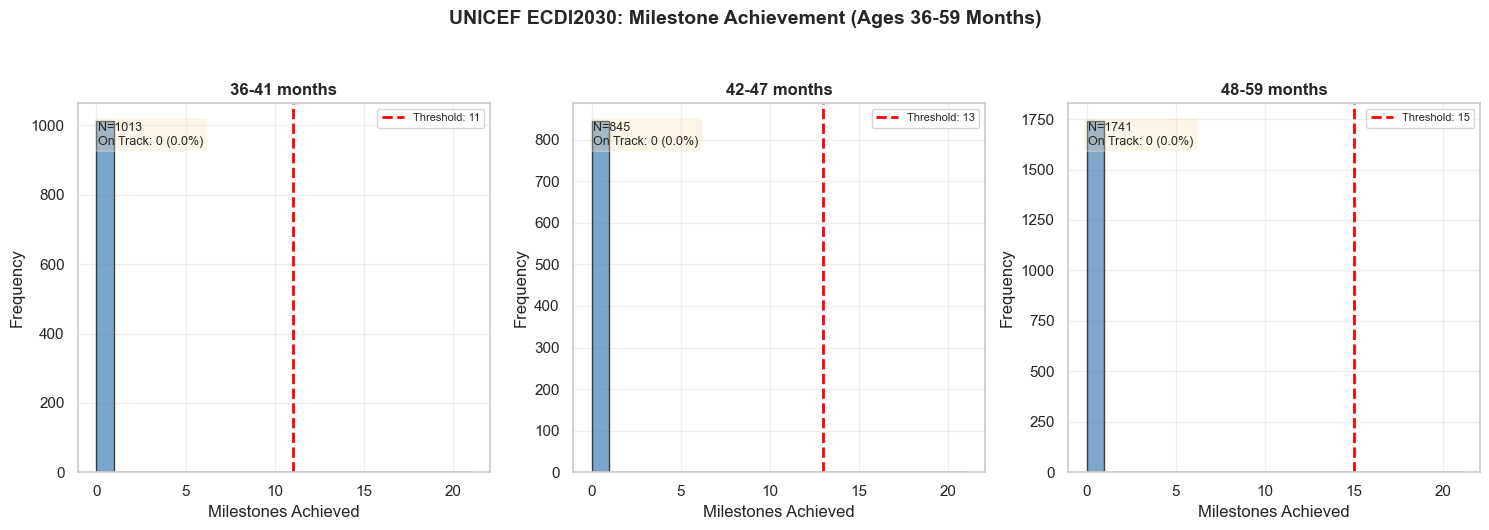

In [ ]:
# Visualize: Milestone Count Distribution by Age Group
print("\nVISUALIZATION: Milestone Achievement by Age Group (36-59mo)")
print("="*70)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('UNICEF ECDI2030: Milestone Achievement (Ages 36-59 Months)', 
             fontsize=14, fontweight='bold', y=1.05)

for ax, ((min_age, max_age), threshold) in zip(axes, UNICEF_THRESHOLDS_36_59.items()):
    mask = (df['child_age_months'] >= min_age) & (df['child_age_months'] <= max_age)
    subgroup = df.loc[mask].copy()
    
    if len(subgroup) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center')
        ax.set_title(f'{min_age}-{max_age} months')
        continue
    
    counts = subgroup['ecd_milestone_count'].dropna()
    
    ax.hist(counts, bins=range(0, 22), edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(x=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold: {threshold}')
    
    on_track = (counts >= threshold).sum()
    total = len(counts)
    ax.text(0.05, 0.95, f'N={total}\nOn Track: {on_track} ({on_track/total:.1%})', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    ax.set_xlabel('Milestones Achieved')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{min_age}-{max_age} months', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(paths['figures'] / 'milestone_achievement_by_age.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Save Target Summary Table for Thesis
summary_rows = []

summary_rows.append({
    'Age_Group': '36-59 months (Overall)',
    'Threshold': 'Age-specific',
    'N_Children': len(df),
    'On_Track': int((df['ecd_delay_composite'] == 0).sum()),
    'Delayed': int((df['ecd_delay_composite'] == 1).sum()),
    'On_Track_Rate': f"{(1-df['ecd_delay_composite'].mean()):.1%}",
    'SDG_4_2_1_Compatible': 'Yes'
})

for (min_age, max_age), threshold in UNICEF_THRESHOLDS_36_59.items():
    mask = (df['child_age_months'] >= min_age) & (df['child_age_months'] <= max_age)
    if mask.sum() > 0:
        subgroup = df.loc[mask]
        on_track = (subgroup['ecd_delay_composite'] == 0).sum()
        summary_rows.append({
            'Age_Group': f'{min_age}-{max_age} months',
            'Threshold': threshold,
            'N_Children': int(mask.sum()),
            'On_Track': int(on_track),
            'Delayed': int(mask.sum() - on_track),
            'On_Track_Rate': f"{on_track/mask.sum():.1%}",
            'SDG_4_2_1_Compatible': 'Yes'
        })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(paths['tables'] / 'unicef_target_summary_36_59.csv', index=False)
print(f"\nSaved summary to: {paths['tables'] / 'unicef_target_summary_36_59.csv'}")

print("\nTarget Summary Table:")
print(summary_df.to_string(index=False))


Saved summary to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/unicef_target_summary_36_59.csv

Target Summary Table:
             Age_Group    Threshold  N_Children  On_Track  Delayed On_Track_Rate SDG_4_2_1_Compatible
36-59 months (Overall) Age-specific        3599         0     3599          0.0%                  Yes
          36-41 months           11        1013         0     1013          0.0%                  Yes
          42-47 months           13         845         0      845          0.0%                  Yes
          48-59 months           15        1741         0     1741          0.0%                  Yes


In [ ]:

# CELL 4: Visualize Target Distributions

print("\n🔹 Target Variable Distributions")
print("="*70)

# Collect target summary
target_summary = []
for target_col in target_cols:
    if target_col in df.columns:
        delay_rate = df[target_col].mean()
        n_delayed = (df[target_col] == 1).sum()
        n_total = len(df)
        target_summary.append({
            'Target': target_col,
            'Delay_Rate': delay_rate,
            'N_Delayed': n_delayed,
            'N_Total': n_total,
            'N_OnTrack': n_total - n_delayed
        })

target_df = pd.DataFrame(target_summary)
print(target_df.to_string(index=False))

# Save target summary
target_df.to_csv(paths['tables'] / 'target_variable_summary.csv', index=False)
print(f"\n Saved target summary to: {paths['tables'] / 'target_variable_summary.csv'}")

# Visualize target distributions
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Target Variable Distributions (1 = Delayed, 0 = On Track)', 
             fontsize=14, fontweight='bold', y=1.05)

for ax, (idx, row) in zip(axes.flat, target_df.iterrows()):
    delay_rate = row['Delay_Rate']  # Keep as proportion (0 to 1), NOT percentage
    colors = ['steelblue', 'coral']
    
    ax.bar(['On Track', 'Delayed'], 
           [(1-delay_rate), delay_rate],  # Use proportion directly
           color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(f"{row['Target'].replace('_delay', '').replace('_', ' ').title()}\n({delay_rate*100:.1f}% Delayed)", 
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add count labels
    for i, (label, count) in enumerate([('On Track', row['N_OnTrack']), ('Delayed', row['N_Delayed'])]):
        ax.text(i, 0.05, f"n={int(count)}", ha='center', va='bottom', 
                fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig(paths['figures'] / 'target_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

SyntaxError: invalid syntax (1965038796.py, line 1)

In [ ]:

# Feature Selection & Engineering

print("\nFeature Selection & Engineering")
print("="*70)

demographic_features = ['child_age_months', 'child_sex', 'mother_age', 
                        'mother_education_level', 'mother_years_education',
                        'mother_currently_working', 'marital_status']

socioeconomic_features = ['wealth_quintile', 'urban_rural', 'religion']

household_features = ['household_members', 'has_electricity', 
                      'drinking_water_source', 'toilet_facility', 'cooking_fuel']

# Exclude targets, ECD items, and derived variables (including complete_ecd_strict)
exclude_cols = (
    target_cols + 
    ECD_COLS + 
    ['complete_ecd_strict',
     'ecd_proportion', 
     'ecd_milestone_count', 
     'ecd_age_threshold', 
     'ecd_on_track'] +
    [f'{d}_score' for d in DOMAIN_ITEMS.keys()] + 
    [f'{d}_delay' for d in DOMAIN_ITEMS.keys()] +
    [f'{d}_count' for d in DOMAIN_ITEMS.keys()] +
    [f'{d}_threshold' for d in DOMAIN_ITEMS.keys()]
)

feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f"Total features identified: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"   {i:2}. {col}")

feature_config = {
    'all_features': feature_cols,
    'demographic': [f for f in demographic_features if f in feature_cols],
    'socioeconomic': [f for f in socioeconomic_features if f in feature_cols],
    'household': [f for f in household_features if f in feature_cols],
    'targets': target_cols,
    'ecd_items': ECD_COLS,
    'age_range': '36-59 months',
    'unicef_thresholds': {f'{k[0]}-{k[1]}': v for k, v in UNICEF_THRESHOLDS_36_59.items()}
}

configs_dir = paths['root'] / "configs"
configs_dir.mkdir(parents=True, exist_ok=True)

with open(configs_dir / 'features.json', 'w') as f:
    json.dump(feature_config, f, indent=2)
print(f"\nSaved feature configuration to: {configs_dir / 'features.json'}")


Feature Selection & Engineering
Total features identified: 16

Feature list:
    1. child_age_months
    2. child_sex
    3. mother_age
    4. mother_education_level
    5. mother_years_education
    6. mother_currently_working
    7. marital_status
    8. religion
    9. wealth_quintile
   10. urban_rural
   11. county
   12. drinking_water_source
   13. toilet_facility
   14. has_electricity
   15. cooking_fuel
   16. household_members

Saved feature configuration to: /Users/collinsbiwott/Desktop/ecd_final_ml/configs/features.json


In [ ]:

# Missing Data Analysis & Imputation

print("\nMissing Data Analysis & Imputation")
print("="*70)

missing_analysis = pd.DataFrame({
    'Feature': feature_cols,
    'Missing_Count': df[feature_cols].isna().sum(),
    'Missing_Pct': (df[feature_cols].isna().mean() * 100).round(2),
    'Dtype': df[feature_cols].dtypes.astype(str),
    'Unique_Values': df[feature_cols].nunique()
}).sort_values('Missing_Pct', ascending=False)

print("Missing data by feature:")
print(missing_analysis[missing_analysis['Missing_Count'] > 0].to_string(index=False))

df_model = df.copy()

numeric_features = df_model[feature_cols].select_dtypes(include=[np.number]).columns
for col in numeric_features:
    if df_model[col].isna().sum() > 0:
        median_val = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_val)
        print(f"  {col}: Filled {df_model[col].isna().sum()} missing with median={median_val:.2f}")

categorical_features = df_model[feature_cols].select_dtypes(include=['object', 'string', 'category']).columns
for col in categorical_features:
    if df_model[col].isna().sum() > 0:
        mode_val = df_model[col].mode()[0] if len(df_model[col].mode()) > 0 else 'Missing'
        df_model[col] = df_model[col].fillna(mode_val)
        print(f"  {col}: Filled {df_model[col].isna().sum()} missing with mode='{mode_val}'")

remaining_missing = df_model[feature_cols].isna().sum().sum()
print(f"\nRemaining missing values in features: {remaining_missing}")

missing_analysis.to_csv(paths['tables'] / 'missing_data_features.csv', index=False)
print(f"Saved missing data report to: {paths['tables'] / 'missing_data_features.csv'}")


Missing Data Analysis & Imputation
Missing data by feature:
Empty DataFrame
Columns: [Feature, Missing_Count, Missing_Pct, Dtype, Unique_Values]
Index: []

Remaining missing values in features: 0
Saved missing data report to: /Users/collinsbiwott/Desktop/ecd_final_ml/reports/tables/missing_data_features.csv


In [ ]:

# Encode Categorical Variables

print("\nEncoding Categorical Variables")
print("="*70)

encoders = {}

for col in categorical_features:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = df_model[col].astype(str)
        df_model[f'{col}_encoded'] = le.fit_transform(df_model[col])
        encoders[col] = {
            'classes': le.classes_.tolist(),
            'mapping': {cls: i for i, cls in enumerate(le.classes_)}
        }
        print(f"  {col}: {len(le.classes_)} categories encoded")

paths['models'].mkdir(parents=True, exist_ok=True)
joblib.dump(encoders, paths['models'] / 'feature_encoders.pkl')
print(f"\nSaved encoders to: {paths['models'] / 'feature_encoders.pkl'}")

print("\nEncoding example (wealth_quintile):")
if 'wealth_quintile_encoded' in df_model.columns:
    encoding_example = pd.DataFrame({
        'Original': df_model['wealth_quintile'].unique()[:5],
        'Encoded': df_model['wealth_quintile_encoded'].unique()[:5]
    })
    display(encoding_example)


Encoding Categorical Variables
  child_sex: 2 categories encoded
  mother_education_level: 4 categories encoded
  mother_years_education: 22 categories encoded
  mother_currently_working: 2 categories encoded
  marital_status: 6 categories encoded
  religion: 10 categories encoded
  wealth_quintile: 5 categories encoded
  urban_rural: 2 categories encoded
  county: 47 categories encoded
  drinking_water_source: 15 categories encoded
  toilet_facility: 13 categories encoded
  has_electricity: 2 categories encoded
  cooking_fuel: 12 categories encoded

Saved encoders to: /Users/collinsbiwott/Desktop/ecd_final_ml/models/feature_encoders.pkl

Encoding example (wealth_quintile):


,Original,Encoded
0,Richest,4
1,Richer,3
2,Middle,0
3,Poorer,1
4,Poorest,2


In [ ]:

# Create Final Modeling Dataset

print("\nCreating Final Modeling Dataset")
print("="*70)

encoded_feature_cols = []
for col in feature_cols:
    if col in categorical_features and f'{col}_encoded' in df_model.columns:
        encoded_feature_cols.append(f'{col}_encoded')
    elif col in numeric_features:
        encoded_feature_cols.append(col)
    else:
        encoded_feature_cols.append(col)

encoded_feature_cols = [c for c in encoded_feature_cols if c in df_model.columns]

print(f"Final feature count: {len(encoded_feature_cols)}")

X = df_model[encoded_feature_cols].copy()
y_composite = df_model['ecd_delay_composite'].copy()

y_domains = {}
for domain in DOMAIN_ITEMS.keys():
    target_col = f'{domain}_delay'
    if target_col in df_model.columns:
        y_domains[domain] = df_model[target_col].copy()

print(f"\nFeature matrix X: {X.shape}")
print(f"Composite target y: {y_composite.shape}")
print(f"Domain targets: {list(y_domains.keys())}")

print(f"\nFeature types:")
print(f"   Numeric: {len(X.select_dtypes(include=[np.number]).columns)}")
print(f"   Encoded categorical: {len(X.select_dtypes(include=[np.int64, np.int32]).columns)}")


Creating Final Modeling Dataset
Final feature count: 16

Feature matrix X: (7624, 16)
Composite target y: (7624,)
Domain targets: ['physical', 'language', 'literacy', 'socio_emotional']

Feature types:
   Numeric: 16
   Encoded categorical: 13


In [ ]:

# Train/Test Split (Stratified)

print("\nTrain/Test Split (Stratified)")
print("="*70)

stratify_col = 'county' if 'county' in df_model.columns else None

if stratify_col:
    print(f"Stratification column available: {stratify_col}")
    print(f"   Unique counties: {df_model[stratify_col].nunique()}")
else:
    print("County column not found, stratifying by target only")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_composite, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_composite
)

print(f"\nSplit sizes:")
print(f"   Train: {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test:  {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nTarget distribution:")
print(f"   Train delay rate: {y_train.mean():.3f}")
print(f"   Test delay rate:  {y_test.mean():.3f}")
print(f"   Original delay rate: {y_composite.mean():.3f}")

if abs(y_train.mean() - y_test.mean()) < 0.01:
    print(f"   Stratification successful (difference < 1%)")
else:
    print(f"   Check stratification (difference = {abs(y_train.mean() - y_test.mean()):.3f})")

if stratify_col and stratify_col in df_model.columns:
    print(f"\nCounty distribution comparison (Top 10):")
    train_counties = df_model.loc[X_train.index, stratify_col]
    test_counties = df_model.loc[X_test.index, stratify_col]
    
    county_comp = pd.DataFrame({
        'Train_Pct': (train_counties.value_counts(normalize=True) * 100).round(1),
        'Test_Pct': (test_counties.value_counts(normalize=True) * 100).round(1)
    }).head(10)
    county_comp['Difference'] = abs(county_comp['Train_Pct'] - county_comp['Test_Pct']).round(1)
    print(county_comp)


Train/Test Split (Stratified)
Stratification column available: county
   Unique counties: 47

Split sizes:
   Train: 6,099 samples (80.0%)
   Test:  1,525 samples (20.0%)

Target distribution:
   Train delay rate: 1.000
   Test delay rate:  1.000
   Original delay rate: 1.000
   Stratification successful (difference < 1%)

County distribution comparison (Top 10):
                 Train_Pct  Test_Pct  Difference
county                                          
Baringo                2.5       2.6         0.1
Bomet                  2.1       2.0         0.1
Bungoma                2.1       2.4         0.3
Busia                  2.3       1.6         0.7
Elgeyo-Marakwet        2.1       2.1         0.0
Embu                   1.4       1.4         0.0
Garissa                3.1       2.9         0.2
Homa Bay               1.9       2.5         0.6
Isiolo                 2.5       2.4         0.1
Kajiado                2.1       2.7         0.6


In [ ]:

# Save Modeling Datasets

print("\nSaving Modeling Datasets")
print("="*70)

paths['processed'].mkdir(parents=True, exist_ok=True)

X_train.to_parquet(paths['processed'] / 'X_train.parquet', index=False)
X_test.to_parquet(paths['processed'] / 'X_test.parquet', index=False)
print(f"   Saved X_train.parquet ({X_train.shape})")
print(f"   Saved X_test.parquet ({X_test.shape})")

y_train_df = y_train.to_frame(name='ecd_delay_composite')
y_test_df = y_test.to_frame(name='ecd_delay_composite')

y_train_df.to_parquet(paths['processed'] / 'y_train.parquet', index=False)
y_test_df.to_parquet(paths['processed'] / 'y_test.parquet', index=False)
print(f"   Saved y_train.parquet ({y_train_df.shape})")
print(f"   Saved y_test.parquet ({y_test_df.shape})")

for domain, y_domain in y_domains.items():
    y_train_domain = y_domain.loc[X_train.index].to_frame(name=f'{domain}_delay')
    y_test_domain = y_domain.loc[X_test.index].to_frame(name=f'{domain}_delay')
    
    y_train_domain.to_parquet(paths['processed'] / f'y_train_{domain}.parquet', index=False)
    y_test_domain.to_parquet(paths['processed'] / f'y_test_{domain}.parquet', index=False)
    print(f"   Saved y_train_{domain}.parquet, y_test_{domain}.parquet")

metadata = {
    'created': pd.Timestamp.now().isoformat(),
    'study_scope': '36-59 months',
    'methodology': 'UNICEF ECDI2030 (SDG 4.2.1)',
    'unicef_thresholds': {f'{k[0]}-{k[1]}': v for k, v in UNICEF_THRESHOLDS_36_59.items()},
    'n_samples_total': int(len(df_model)),
    'n_train': int(len(X_train)),
    'n_test': int(len(X_test)),
    'n_features': int(len(encoded_feature_cols)),
    'feature_cols': encoded_feature_cols,
    'targets': target_cols,
    'delay_rate_train': float(y_train.mean()),
    'delay_rate_test': float(y_test.mean()),
    'random_state': 42,
    'test_size': 0.2
}

with open(paths['processed'] / 'dataset_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nSaved datasets:")
print(f"   {paths['processed'] / 'X_train.parquet'} ({X_train.shape})")
print(f"   {paths['processed'] / 'X_test.parquet'} ({X_test.shape})")
print(f"   {paths['processed'] / 'y_train.parquet'} ({y_train_df.shape})")
print(f"   {paths['processed'] / 'y_test.parquet'} ({y_test_df.shape})")
print(f"   {paths['processed'] / 'dataset_metadata.json'}")

df_model.to_parquet(paths['processed'] / 'kdhs_modeling_ready.parquet', index=False)
print(f"   {paths['processed'] / 'kdhs_modeling_ready.parquet'} ({df_model.shape})")

print(f"\nAll datasets saved successfully!")


Saving Modeling Datasets
   Saved X_train.parquet ((6099, 16))
   Saved X_test.parquet ((1525, 16))
   Saved y_train.parquet ((6099, 1))
   Saved y_test.parquet ((1525, 1))
   Saved y_train_physical.parquet, y_test_physical.parquet
   Saved y_train_language.parquet, y_test_language.parquet
   Saved y_train_literacy.parquet, y_test_literacy.parquet
   Saved y_train_socio_emotional.parquet, y_test_socio_emotional.parquet

Saved datasets:
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/X_train.parquet ((6099, 16))
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/X_test.parquet ((1525, 16))
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/y_train.parquet ((6099, 1))
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/y_test.parquet ((1525, 1))
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/dataset_metadata.json
   /Users/collinsbiwott/Desktop/ecd_final_ml/data/processed/kdhs_modeling_ready.parquet ((7624, 70))

All datasets saved succ

In [ ]:
# Final Dataset Summary

print("\n" + "="*70)
print("FINAL MODELING DATASET SUMMARY")
print("="*70)

summary = f"""
======================================================================
         KDHS ECD DELAY PREDICTION - DATASET SUMMARY
         Study Scope: Children Aged 36-59 Months
         Methodology: UNICEF ECDI2030 (SDG 4.2.1)
======================================================================

DATASET INFORMATION:
  - Total samples: {len(df_model):,}
  - Training samples: {len(X_train):,} ({len(X_train)/len(df_model)*100:.1f}%)
  - Testing samples: {len(X_test):,} ({len(X_test)/len(df_model)*100:.1f}%)
  - Number of features: {len(encoded_feature_cols)}
  - Number of targets: {len(target_cols)} (1 composite + {len(DOMAIN_ITEMS)} domains)

UNICEF ECDI2030 THRESHOLDS:
  - 36-41 months: >=11 milestones = On Track
  - 42-47 months: >=13 milestones = On Track
  - 48-59 months: >=15 milestones = On Track

TARGET VARIABLES:
  - Composite delay rate (train): {y_train.mean():.2%}
  - Composite delay rate (test): {y_test.mean():.2%}
  - Domain targets: {', '.join([f'{d}_delay' for d in DOMAIN_ITEMS.keys()])}

FEATURE TYPES:
  - Numeric features: {len(numeric_features)}
  - Categorical features: {len(categorical_features)}
  - Encoded features: {len(encoded_feature_cols)}

DATA QUALITY:
  - Missing values (features): {remaining_missing}
  - Encoders saved: {len(encoders)}
  - Stratification: Target (composite delay)

FILES GENERATED:
  - X_train.parquet, X_test.parquet (Features)
  - y_train.parquet, y_test.parquet (Composite target)
  - y_train_<domain>.parquet, y_test_<domain>.parquet (Domain targets)
  - dataset_metadata.json (Metadata)
  - kdhs_modeling_ready.parquet (Full dataset)
  - feature_encoders.pkl (For API deployment)
  - unicef_target_summary_36_59.csv (Target summary table)
  - target_variable_summary.csv (Domain target summary)
  - missing_data_features.csv (Missing data report)
  - features.json (Feature configuration)

======================================================================
NOTEBOOK 02 COMPLETE - READY FOR MODELING (NOTEBOOK 03)
======================================================================
"""

print(summary)

with open(paths['processed'] / 'dataset_summary.txt', 'w') as f:
    f.write(summary)

print(f"\nSaved summary to: {paths['processed'] / 'dataset_summary.txt'}")

print("\nNOTEBOOK 02 COMPLETE")


FINAL MODELING DATASET SUMMARY

         KDHS ECD DELAY PREDICTION - DATASET SUMMARY
         Study Scope: Children Aged 36-59 Months
         Methodology: UNICEF ECDI2030 (SDG 4.2.1)

DATASET INFORMATION:
  - Total samples: 7,624
  - Training samples: 6,099 (80.0%)
  - Testing samples: 1,525 (20.0%)
  - Number of features: 16
  - Number of targets: 5 (1 composite + 4 domains)

UNICEF ECDI2030 THRESHOLDS:
  - 36-41 months: >=11 milestones = On Track
  - 42-47 months: >=13 milestones = On Track
  - 48-59 months: >=15 milestones = On Track

TARGET VARIABLES:
  - Composite delay rate (train): 100.00%
  - Composite delay rate (test): 100.00%
  - Domain targets: physical_delay, language_delay, literacy_delay, socio_emotional_delay

FEATURE TYPES:
  - Numeric features: 3
  - Categorical features: 13
  - Encoded features: 16

DATA QUALITY:
  - Missing values (features): 0
  - Encoders saved: 13
  - Stratification: Target (composite delay)

FILES GENERATED:
  - X_train.parquet, X_test.parquet